# Per-Asset LSTM Training Notebook (Seq Length Tuning up to 30)
## Edit from lstm_training_2.ipynb
- In this notebook only a subset of the original set of features is applied

This notebook is adapted to your current project structure:

- raw and split CSV files live in `data/`
- preprocessed per-asset LSTM arrays live in `lstm_ready_data/`
- one LSTM model is trained **per asset**
- two variants are compared for every asset:
  - **baseline**: without the regime indicator
  - **regime-aware**: with the regime indicator

The notebook does three things in sequence:

1. checks the split boundaries and the 7-day target logic
2. tunes hyperparameters with **expanding-window CV on the train split only**
3. produces **7-day-ahead OOS forecasts** on validation and test

The sequence-length search is capped at **30** because the preprocessing notebook saved windows with `LOOKBACK = 30`. That means the training notebook can test shorter windows by slicing the saved arrays, but it cannot test anything longer than the saved base window.

- this version also supports running multiple **feature subsets** by dropping unused columns from the saved arrays before tuning, validation forecasting, and test forecasting.


## How to think about the saved `.npy` arrays

Each per-asset array already contains sliding windows.

For example, if preprocessing used `LOOKBACK = 30`, then a file like `X_train_BTCUSDT.npy` has shape:

\[
(	ext{samples}, 30, 	ext{features})
\]

So one sample is already a **30-day sequence**. During hyperparameter tuning, if we test `seq_len = 15`, we do **not** rebuild the window from scratch. We simply keep the **last 15 timesteps** from each saved 30-day block.

Example:

- saved sample: days `t-29` to `t`
- if `seq_len = 15`, the model sees only days `t-14` to `t`

That is why sequence-length tuning here is limited to values `<= 30`.


In [26]:
from pathlib import Path
import json
import random
import itertools
import math
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader


## Configuration

This cell controls the directories, loss, search space, and tuning behaviour.

A few important design choices:

- `LOSS_NAME = "mse"` keeps the objective aligned with your forecasting goal.
- hyperparameter tuning is done on **train only** using expanding-window splits.
- the validation split is used only for **OOS validation forecasts** after tuning.
- the test split is used only for **final OOS test forecasts** after tuning and refitting on train+val.
- sequence lengths are restricted to values `<= 30`.


In [27]:

DATA_DIR = Path("data")
LSTM_DIR = Path("lstm_ready_data")
OUTPUT_DIR = Path("outputs_feature_subsets")
OUTPUT_DIR.mkdir(exist_ok=True)

TRAIN_PATH = DATA_DIR / "train_df.csv"
VAL_PATH   = DATA_DIR / "val_df.csv"
TEST_PATH  = DATA_DIR / "test_df.csv"
RAW_PANEL_PATH = DATA_DIR / "binance_data_raw.csv"

HORIZON = 7
LOSS_NAME = "mse"            # "mse" or "huber"
SEED = 42
USE_GPU_IF_AVAILABLE = True

# -------------------------------------------------------------------
# Saved feature order from `lstm_preprocessing_pipeline.ipynb`
# -------------------------------------------------------------------
CONTINUOUS_FEATURES = [
    "close", "log_return", "open", "high", "low", "volume",
    "vol_30", "sma", "ema", "momentum", "cci"
]
BINARY_FEATURES = ["regime_label"]
SAVED_FEATURE_ORDER = CONTINUOUS_FEATURES + BINARY_FEATURES

# -------------------------------------------------------------------
# Feature-subset configuration
# -------------------------------------------------------------------
# Each entry should contain ONLY the non-regime predictors you want in that run.
# The notebook will append `regime_label` automatically for regime-aware variants.
#
# Edit this dictionary to compare different predictor sets.
FEATURE_SETS = {
    # "all_continuous": CONTINUOUS_FEATURES.copy(),
    # "ohlcv_only": ["close", "log_return", "open", "high", "low", "volume"],
    # "technical_only": ["vol_30", "sma", "ema", "momentum", "cci"],
    "ref_paper_set": ["sma", "ema", "momentum", "cci"]
}

# Toggle to only run a subset of the entries above.
ACTIVE_FEATURE_SET_NAMES = list(FEATURE_SETS.keys())

# Hyperparameter tuning controls
N_CV_SPLITS = 3
RANDOM_SEARCH = True
N_RANDOM_CONFIGS = 36        # increase for a deeper search, reduce if runtime is too long
MAX_SEQ_LEN = 30             # capped by the preprocessing lookback
SEQ_LEN_CANDIDATES = [10, 15, 20, 25, 30]

PARAM_GRID = {
    "seq_len": SEQ_LEN_CANDIDATES,
    "learning_rate": [1e-3, 5e-4, 1e-4],
    "hidden_size": [32, 64, 128],
    "num_layers": [1, 2],
    "dropout": [0.0, 0.1, 0.2, 0.3],
    "batch_size": [32, 64],
    "epochs": [20, 35, 50],
    "weight_decay": [0.0, 1e-5, 1e-4],
    "patience": [5],
}

# Validate the feature-set config early
for feature_set_name, feature_list in FEATURE_SETS.items():
    missing = sorted(set(feature_list) - set(CONTINUOUS_FEATURES))
    if missing:
        raise ValueError(
            f"Feature set '{feature_set_name}' contains columns not found in the saved arrays: {missing}"
        )

ACTIVE_FEATURE_SETS = {
    name: FEATURE_SETS[name]
    for name in ACTIVE_FEATURE_SET_NAMES
}

if not ACTIVE_FEATURE_SETS:
    raise ValueError("ACTIVE_FEATURE_SET_NAMES produced an empty feature-set selection.")

print("Saved feature order:", SAVED_FEATURE_ORDER)
print("Active feature sets:")
for name, cols in ACTIVE_FEATURE_SETS.items():
    print(f"  - {name}: {cols}")


Saved feature order: ['close', 'log_return', 'open', 'high', 'low', 'volume', 'vol_30', 'sma', 'ema', 'momentum', 'cci', 'regime_label']
Active feature sets:
  - ref_paper_set: ['sma', 'ema', 'momentum', 'cci']


## Reproducibility and device setup

The seed makes the random search and PyTorch training more stable across runs. The notebook will use GPU if PyTorch can see one.


In [28]:
def seed_everything(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)
device = "cuda" if (USE_GPU_IF_AVAILABLE and torch.cuda.is_available()) else "cpu"
print("Using device:", device)


Using device: cpu


## Load split CSVs and detect assets from the saved `.npy` files

The CSVs are used for boundary checks and for rebuilding the date metadata that tells us which forecast belongs to which asset/date. The actual model inputs come from the per-asset `.npy` arrays.


In [29]:
def sort_panel(df: pd.DataFrame) -> pd.DataFrame:
    return df.sort_values(["crypto", "date"]).reset_index(drop=True)

train_df = sort_panel(pd.read_csv(TRAIN_PATH, parse_dates=["date"]))
val_df   = sort_panel(pd.read_csv(VAL_PATH,   parse_dates=["date"]))
test_df  = sort_panel(pd.read_csv(TEST_PATH,  parse_dates=["date"]))

train_files = sorted(LSTM_DIR.glob("X_train_*.npy"))
assets = [p.stem.replace("X_train_", "") for p in train_files]

print("Train CSV shape:", train_df.shape)
print("Val CSV shape:  ", val_df.shape)
print("Test CSV shape: ", test_df.shape)
print("Detected assets:", assets)

if not assets:
    raise FileNotFoundError(
        f"No per-asset X_train_*.npy files found in {LSTM_DIR.resolve()}."
    )


Train CSV shape: (11448, 15)
Val CSV shape:   (2928, 15)
Test CSV shape:  (2864, 15)
Detected assets: ['ADAUSDT', 'BCHUSDT', 'BNBUSDT', 'BTCUSDT', 'ETHUSDT', 'LINKUSDT', 'LTCUSDT', 'XRPUSDT']


## Boundary and leakage sanity checks

The `target_7d` on a row dated `t` is meant to represent the return from `t+1` to `t+7`.

That means:

- the **last 7 rows** of train cannot safely be used for train targets if they would spill into validation
- the **last 7 rows** of validation cannot safely be used for validation targets if they would spill into test

The preprocessing notebook handled this by trimming the last 7 rows of each asset in train and validation before sequence creation. The code below rebuilds the same logic so we can verify the boundaries.


In [30]:
def trim_split_for_horizon(df: pd.DataFrame, horizon: int) -> pd.DataFrame:
    trimmed = []
    for asset, sub in df.groupby("crypto", sort=True):
        sub = sub.sort_values("date").copy()
        if len(sub) <= horizon:
            raise ValueError(f"Asset {asset} has only {len(sub)} rows; cannot trim horizon={horizon}.")
        trimmed.append(sub.iloc[:-horizon].copy())
    return pd.concat(trimmed, ignore_index=True)

safe_train = trim_split_for_horizon(train_df, HORIZON)
safe_val   = trim_split_for_horizon(val_df, HORIZON)
safe_test  = test_df.copy()  # preprocessing notebook assumes test was already made safe upstream

summary_rows = []
for split_name, df_ in {
    "train_raw": train_df,
    "train_safe": safe_train,
    "val_raw": val_df,
    "val_safe": safe_val,
    "test_used": safe_test,
}.items():
    counts = df_.groupby("crypto").size()
    summary_rows.append({
        "split": split_name,
        "date_min": df_["date"].min(),
        "date_max": df_["date"].max(),
        "rows_per_asset_min": int(counts.min()),
        "rows_per_asset_max": int(counts.max()),
    })

boundary_summary = pd.DataFrame(summary_rows)
display(boundary_summary)

if RAW_PANEL_PATH.exists():
    raw_panel = sort_panel(pd.read_csv(RAW_PANEL_PATH, parse_dates=["date"]))
    raw_max = raw_panel.groupby("crypto")["date"].max().rename("raw_max_date")
    test_max = test_df.groupby("crypto")["date"].max().rename("test_max_date")
    check = pd.concat([raw_max, test_max], axis=1).reset_index()
    check["days_between_raw_and_test_max"] = (check["raw_max_date"] - check["test_max_date"]).dt.days
    print("Optional raw-vs-test end-date check:")
    display(check)
else:
    print("Optional raw panel check skipped because data/binance_data_raw.csv was not found.")


,split,date_min,date_max,rows_per_asset_min,rows_per_asset_max
0,train_raw,2020-01-31,2023-12-31,1431,1431
1,train_safe,2020-01-31,2023-12-24,1424,1424
2,val_raw,2024-01-01,2024-12-31,366,366
3,val_safe,2024-01-01,2024-12-24,359,359
4,test_used,2025-01-01,2025-12-24,358,358


Optional raw-vs-test end-date check:


,crypto,raw_max_date,test_max_date,days_between_raw_and_test_max
0,ADAUSDT,2025-12-24,2025-12-24,0
1,BCHUSDT,2025-12-24,2025-12-24,0
2,BNBUSDT,2025-12-24,2025-12-24,0
3,BTCUSDT,2025-12-24,2025-12-24,0
4,ETHUSDT,2025-12-24,2025-12-24,0
5,LINKUSDT,2025-12-24,2025-12-24,0
6,LTCUSDT,2025-12-24,2025-12-24,0
7,XRPUSDT,2025-12-24,2025-12-24,0


## Rebuild metadata for each asset

The preprocessing notebook saved the `.npy` tensors, but for evaluation we still want to know:

- which asset a forecast belongs to
- which forecast-origin date the sample corresponds to

Because the per-asset `.npy` arrays were built with the original `LOOKBACK = 30`, we can rebuild the metadata from the CSV splits and then assert that the number of rebuilt dates matches the number of saved targets.


In [31]:
def load_asset_arrays(asset: str, data_dir: Path = LSTM_DIR):
    X_train = np.load(data_dir / f"X_train_{asset}.npy")
    y_train = np.load(data_dir / f"y_train_{asset}.npy")
    X_val   = np.load(data_dir / f"X_val_{asset}.npy")
    y_val   = np.load(data_dir / f"y_val_{asset}.npy")
    X_test  = np.load(data_dir / f"X_test_{asset}.npy")
    y_test  = np.load(data_dir / f"y_test_{asset}.npy")
    return X_train, y_train, X_val, y_val, X_test, y_test


def rebuild_meta_dates_for_asset(asset: str, base_lookback: int):
    train_asset = train_df[train_df["crypto"] == asset].sort_values("date").copy()
    val_asset   = val_df[val_df["crypto"] == asset].sort_values("date").copy()
    test_asset  = test_df[test_df["crypto"] == asset].sort_values("date").copy()

    train_safe_asset = train_asset.iloc[:-HORIZON].copy()
    val_safe_asset   = val_asset.iloc[:-HORIZON].copy()
    test_safe_asset  = test_asset.copy()

    def build_meta(current_df: pd.DataFrame, history_df: pd.DataFrame | None):
        if history_df is not None:
            combined = pd.concat([history_df, current_df], ignore_index=True)
            combined = (
                combined.drop_duplicates(subset=["date"], keep="last")
                        .sort_values("date")
                        .reset_index(drop=True)
            )
        else:
            combined = current_df.sort_values("date").reset_index(drop=True)

        current_dates = set(current_df["date"])
        dates = combined["date"].to_numpy()
        rows = []

        for end_idx in range(base_lookback - 1, len(combined)):
            if pd.Timestamp(dates[end_idx]) not in current_dates:
                continue
            rows.append({"crypto": asset, "date": pd.Timestamp(dates[end_idx])})

        return pd.DataFrame(rows)

    meta_train = build_meta(train_safe_asset, history_df=None)
    meta_val   = build_meta(val_safe_asset,   history_df=train_safe_asset)
    meta_test  = build_meta(test_safe_asset,  history_df=pd.concat([train_safe_asset, val_safe_asset], ignore_index=True))
    return meta_train, meta_val, meta_test

# Quick shape inspection using the first asset
example_asset = assets[0]
X_train_ex, y_train_ex, X_val_ex, y_val_ex, X_test_ex, y_test_ex = load_asset_arrays(example_asset)
print(f"Example asset: {example_asset}")
print("X_train shape:", X_train_ex.shape)
print("y_train shape:", y_train_ex.shape)
print("Saved base lookback:", X_train_ex.shape[1])


Example asset: ADAUSDT
X_train shape: (1395, 30, 12)
y_train shape: (1395,)
Saved base lookback: 30


## Model definition

The architecture is intentionally simple and transparent:

- LSTM stack with tunable `num_layers`
- tunable `hidden_size`
- dropout applied only when `num_layers > 1`
- one dense output layer producing a single 7-day-return forecast

This keeps the comparison between baseline and regime-aware models clean.


In [32]:
class CryptoLSTM(nn.Module):
    def __init__(self, input_size: int, hidden_size: int = 64, num_layers: int = 1, dropout: float = 0.0):
        super().__init__()
        effective_dropout = dropout if num_layers > 1 else 0.0
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=effective_dropout,
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        last_hidden = out[:, -1, :]
        pred = self.fc(last_hidden)
        return pred


## Training, prediction, and CV helpers

A few design choices matter here:

- **CV stage**: uses expanding-window train/validation splits inside the train sample and uses early stopping.
- **Validation OOS stage**: after tuning, the model is fit on the full train split for the chosen number of epochs and predicts the validation split.
- **Test OOS stage**: after tuning, the model is refit on **train + validation** for the chosen number of epochs and predicts the test split.

This keeps the final test forecast properly out-of-sample while still letting you use more data before the final test forecast.


In [33]:
def get_loss_fn(loss_name: str):
    if loss_name.lower() == "mse":
        return nn.MSELoss()
    if loss_name.lower() == "huber":
        return nn.HuberLoss(delta=1.0)
    raise ValueError("LOSS_NAME must be 'mse' or 'huber'.")


def mse_score(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return float(np.mean((y_true - y_pred) ** 2))


def mae_score(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return float(np.mean(np.abs(y_true - y_pred)))


def directional_accuracy(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return float(np.mean(np.sign(y_true) == np.sign(y_pred)))


def make_loader(X, y, batch_size: int, shuffle: bool):
    X_tensor = torch.tensor(X, dtype=torch.float32)
    y_tensor = torch.tensor(y, dtype=torch.float32).view(-1, 1)
    ds = TensorDataset(X_tensor, y_tensor)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)


def fit_model(
    model,
    train_loader,
    lr: float,
    epochs: int,
    loss_name: str,
    weight_decay: float = 0.0,
    device: str = "cpu",
    val_loader=None,
    patience: int | None = None,
):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = get_loss_fn(loss_name)

    best_state = None
    best_val_loss = float("inf")
    epochs_no_improve = 0
    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        model.train()
        running_train = 0.0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()
            pred = model(X_batch)
            loss = criterion(pred, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            running_train += loss.item() * X_batch.size(0)

        train_loss = running_train / len(train_loader.dataset)
        train_losses.append(train_loss)

        if val_loader is not None:
            model.eval()
            running_val = 0.0
            with torch.no_grad():
                for X_batch, y_batch in val_loader:
                    X_batch = X_batch.to(device)
                    y_batch = y_batch.to(device)
                    pred = model(X_batch)
                    loss = criterion(pred, y_batch)
                    running_val += loss.item() * X_batch.size(0)

            val_loss = running_val / len(val_loader.dataset)
            val_losses.append(val_loss)

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
                epochs_no_improve = 0
            else:
                epochs_no_improve += 1

            if patience is not None and epochs_no_improve >= patience:
                break

    if val_loader is not None and best_state is not None:
        model.load_state_dict(best_state)

    history = {
        "train_losses": train_losses,
        "val_losses": val_losses,
        "best_val_loss": best_val_loss if val_loader is not None else None,
        "epochs_trained": len(train_losses),
    }
    return model, history


def predict_model(model, X, device: str = "cpu", batch_size: int = 512):
    model = model.to(device)
    model.eval()
    preds = []
    loader = DataLoader(torch.tensor(X, dtype=torch.float32), batch_size=batch_size, shuffle=False)
    with torch.no_grad():
        for X_batch in loader:
            X_batch = X_batch.to(device)
            batch_pred = model(X_batch).detach().cpu().numpy().reshape(-1)
            preds.append(batch_pred)
    return np.concatenate(preds)


def expanding_window_splits(n_obs: int, n_splits: int = 3, train_frac: float = 0.60, val_frac: float = 0.20):
    initial_train = max(30, int(n_obs * train_frac))
    val_size = max(15, int(n_obs * val_frac))

    if initial_train + val_size >= n_obs:
        raise ValueError("Training set is too short for the requested expanding-window CV setup.")

    remaining = n_obs - initial_train - val_size
    step = max(1, remaining // max(n_splits - 1, 1))

    splits = []
    for i in range(n_splits):
        train_end = initial_train + i * step
        val_start = train_end
        val_end = val_start + val_size
        if val_end <= n_obs:
            train_idx = np.arange(0, train_end)
            val_idx = np.arange(val_start, val_end)
            splits.append((train_idx, val_idx))

    if not splits:
        raise ValueError("No valid CV splits were created. Reduce n_splits or val_frac.")
    return splits


## Hyperparameter search space

The full grid is large, so by default this notebook uses **random search** over that grid. This is usually a better trade-off than exhaustive grid search when you have many assets and two model variants per asset.

Because the saved arrays already have a fixed base lookback, configs with `seq_len > saved_lookback` are dropped automatically.


In [34]:
all_configs = [dict(zip(PARAM_GRID.keys(), values)) for values in itertools.product(*PARAM_GRID.values())]

if RANDOM_SEARCH:
    n_pick = min(N_RANDOM_CONFIGS, len(all_configs))
    search_configs = random.sample(all_configs, k=n_pick)
else:
    search_configs = all_configs

print(f"Total possible configs: {len(all_configs)}")
print(f"Configs to evaluate:    {len(search_configs)}")
print("Candidate sequence lengths:", SEQ_LEN_CANDIDATES)


Total possible configs: 6480
Configs to evaluate:    36
Candidate sequence lengths: [10, 15, 20, 25, 30]



## Tuning logic
### NOTE: changes applied here to load subset of features instead of full

Before the model sees any data, the notebook now does two transformations:

1. it selects a named **feature subset** from the saved arrays by dropping unused feature columns
2. if `use_regime = True`, it appends `regime_label`; otherwise it excludes `regime_label`
3. if `seq_len < saved_lookback`, it slices the last `seq_len` timesteps from each saved window

This means the same preprocessed `.npy` arrays can be reused for many model specifications without rebuilding the windows from scratch.


In [35]:

def apply_seq_len(X: np.ndarray, seq_len: int) -> np.ndarray:
    if seq_len > X.shape[1]:
        raise ValueError(f"Requested seq_len={seq_len} but saved windows only have length {X.shape[1]}.")
    return X[:, -seq_len:, :]


def get_feature_indices(
    selected_feature_names: list[str],
    use_regime: bool,
    saved_feature_order: list[str] = SAVED_FEATURE_ORDER,
) -> list[int]:
    final_feature_names = list(selected_feature_names)
    if use_regime:
        final_feature_names = final_feature_names + ["regime_label"]

    missing = [f for f in final_feature_names if f not in saved_feature_order]
    if missing:
        raise ValueError(f"Requested features are not present in saved arrays: {missing}")

    return [saved_feature_order.index(f) for f in final_feature_names]


def select_features_from_saved_array(
    X: np.ndarray,
    selected_feature_names: list[str],
    use_regime: bool,
    saved_feature_order: list[str] = SAVED_FEATURE_ORDER,
) -> np.ndarray:
    idx = get_feature_indices(
        selected_feature_names=selected_feature_names,
        use_regime=use_regime,
        saved_feature_order=saved_feature_order,
    )
    return X[:, :, idx]


def prepare_variant(
    X_full: np.ndarray,
    seq_len: int,
    selected_feature_names: list[str],
    use_regime: bool,
) -> np.ndarray:
    X_variant = select_features_from_saved_array(
        X=X_full,
        selected_feature_names=selected_feature_names,
        use_regime=use_regime,
        saved_feature_order=SAVED_FEATURE_ORDER,
    )
    X_variant = apply_seq_len(X_variant, seq_len)
    return X_variant


def evaluate_config_cv(X_full, y, config, selected_feature_names: list[str], use_regime: bool, device: str):
    X_variant = prepare_variant(
        X_full=X_full,
        seq_len=config["seq_len"],
        selected_feature_names=selected_feature_names,
        use_regime=use_regime,
    )

    cv_losses = []
    splits = expanding_window_splits(len(X_variant), n_splits=N_CV_SPLITS)

    for train_idx, val_idx in splits:
        X_tr, y_tr = X_variant[train_idx], y[train_idx]
        X_va, y_va = X_variant[val_idx], y[val_idx]

        train_loader = make_loader(X_tr, y_tr, batch_size=config["batch_size"], shuffle=True)
        val_loader   = make_loader(X_va, y_va, batch_size=config["batch_size"], shuffle=False)

        model = CryptoLSTM(
            input_size=X_variant.shape[2],
            hidden_size=config["hidden_size"],
            num_layers=config["num_layers"],
            dropout=config["dropout"],
        )

        model, history = fit_model(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            lr=config["learning_rate"],
            epochs=config["epochs"],
            patience=config["patience"],
            loss_name=LOSS_NAME,
            weight_decay=config["weight_decay"],
            device=device,
        )

        cv_losses.append(history["best_val_loss"])

    return float(np.mean(cv_losses))


def tune_variant(
    X_train_full,
    y_train,
    selected_feature_names: list[str],
    feature_set_name: str,
    use_regime: bool,
    search_configs: list[dict],
    device: str,
):
    max_saved_lookback = min(X_train_full.shape[1], MAX_SEQ_LEN)
    valid_configs = [cfg for cfg in search_configs if cfg["seq_len"] <= max_saved_lookback]

    results = []
    best_config = None
    best_score = float("inf")

    for i, cfg in enumerate(valid_configs, start=1):
        score = evaluate_config_cv(
            X_full=X_train_full,
            y=y_train,
            config=cfg,
            selected_feature_names=selected_feature_names,
            use_regime=use_regime,
            device=device,
        )
        results.append({
            "config_id": i,
            "feature_set": feature_set_name,
            "model_type": "regime" if use_regime else "baseline",
            "n_features": len(selected_feature_names) + int(use_regime),
            "cv_mse": score,
            **cfg,
        })

        if score < best_score:
            best_score = score
            best_config = cfg

        print(
            f"[{feature_set_name} | {'REG' if use_regime else 'BASE'}] "
            f"config {i}/{len(valid_configs)} | cv_mse={score:.8f} | {cfg}"
        )

    results_df = pd.DataFrame(results).sort_values("cv_mse").reset_index(drop=True)
    return best_config, results_df



## Final OOS forecast functions

After hyperparameter tuning:

- **validation forecasts** are produced by fitting on the full train split only
- **test forecasts** are produced by refitting on train + validation, then forecasting test

The only extra twist now is that the exact feature subset is applied consistently in all three stages:
CV tuning, validation forecasting, and final test forecasting.


In [36]:

def fit_for_validation_forecast(
    X_train_full,
    y_train,
    X_val_full,
    y_val,
    config,
    selected_feature_names: list[str],
    use_regime: bool,
    device: str,
):
    X_train_variant = prepare_variant(
        X_full=X_train_full,
        seq_len=config["seq_len"],
        selected_feature_names=selected_feature_names,
        use_regime=use_regime,
    )
    X_val_variant = prepare_variant(
        X_full=X_val_full,
        seq_len=config["seq_len"],
        selected_feature_names=selected_feature_names,
        use_regime=use_regime,
    )

    train_loader = make_loader(X_train_variant, y_train, batch_size=config["batch_size"], shuffle=True)
    model = CryptoLSTM(
        input_size=X_train_variant.shape[2],
        hidden_size=config["hidden_size"],
        num_layers=config["num_layers"],
        dropout=config["dropout"],
    )

    model, history = fit_model(
        model=model,
        train_loader=train_loader,
        val_loader=None,
        lr=config["learning_rate"],
        epochs=config["epochs"],
        patience=None,
        loss_name=LOSS_NAME,
        weight_decay=config["weight_decay"],
        device=device,
    )

    val_pred = predict_model(model, X_val_variant, device=device)
    metrics = {
        "val_mse": mse_score(y_val, val_pred),
        "val_mae": mae_score(y_val, val_pred),
        "val_da": directional_accuracy(y_val, val_pred),
    }
    return model, history, val_pred, metrics


def fit_for_test_forecast(
    X_train_full,
    y_train,
    X_val_full,
    y_val,
    X_test_full,
    y_test,
    config,
    selected_feature_names: list[str],
    use_regime: bool,
    device: str,
):
    X_train_variant = prepare_variant(
        X_full=X_train_full,
        seq_len=config["seq_len"],
        selected_feature_names=selected_feature_names,
        use_regime=use_regime,
    )
    X_val_variant = prepare_variant(
        X_full=X_val_full,
        seq_len=config["seq_len"],
        selected_feature_names=selected_feature_names,
        use_regime=use_regime,
    )
    X_test_variant = prepare_variant(
        X_full=X_test_full,
        seq_len=config["seq_len"],
        selected_feature_names=selected_feature_names,
        use_regime=use_regime,
    )

    X_trainval = np.concatenate([X_train_variant, X_val_variant], axis=0)
    y_trainval = np.concatenate([y_train, y_val], axis=0)

    train_loader = make_loader(X_trainval, y_trainval, batch_size=config["batch_size"], shuffle=True)
    model = CryptoLSTM(
        input_size=X_trainval.shape[2],
        hidden_size=config["hidden_size"],
        num_layers=config["num_layers"],
        dropout=config["dropout"],
    )

    model, history = fit_model(
        model=model,
        train_loader=train_loader,
        val_loader=None,
        lr=config["learning_rate"],
        epochs=config["epochs"],
        patience=None,
        loss_name=LOSS_NAME,
        weight_decay=config["weight_decay"],
        device=device,
    )

    test_pred = predict_model(model, X_test_variant, device=device)
    metrics = {
        "test_mse": mse_score(y_test, test_pred),
        "test_mae": mae_score(y_test, test_pred),
        "test_da": directional_accuracy(y_test, test_pred),
    }
    return model, history, test_pred, metrics



## Main training loop

This loop now nests over:

1. each asset
2. each named feature subset
3. each model variant (`baseline` without regime, `regime` with regime)

For every combination it:

1. loads the per-asset arrays
2. rebuilds and verifies metadata
3. drops irrelevant columns based on the selected feature subset
4. tunes on the train split with expanding-window CV
5. produces OOS validation forecasts
6. refits on train+val and produces OOS test forecasts
7. saves configs, metrics, histories, forecasts, and final model weights

Outputs are stored under:

`outputs_feature_subsets/<feature_set>/<asset>/...`


In [37]:

all_summary_rows = []
all_forecast_rows = []

for feature_set_name, selected_feature_names in ACTIVE_FEATURE_SETS.items():
    print("\n" + "#" * 110)
    print(f"Running feature set: {feature_set_name}")
    print("Selected non-regime features:", selected_feature_names)

    feature_set_dir = OUTPUT_DIR / feature_set_name
    feature_set_dir.mkdir(exist_ok=True)

    for asset in assets:
        print("=" * 90)
        print("Processing asset:", asset)

        X_train_full, y_train, X_val_full, y_val, X_test_full, y_test = load_asset_arrays(asset)
        base_lookback = X_train_full.shape[1]

        meta_train, meta_val, meta_test = rebuild_meta_dates_for_asset(asset, base_lookback=base_lookback)

        assert len(meta_train) == len(y_train), f"Meta mismatch in train for {asset}"
        assert len(meta_val) == len(y_val), f"Meta mismatch in val for {asset}"
        assert len(meta_test) == len(y_test), f"Meta mismatch in test for {asset}"

        # Asset-specific search space: respect the saved lookback and the hard cap of 30
        asset_search_configs = [cfg for cfg in search_configs if cfg["seq_len"] <= min(base_lookback, MAX_SEQ_LEN)]
        if not asset_search_configs:
            raise ValueError(f"No valid configs remain for {asset}. Saved lookback is {base_lookback}.")

        # -------------------------------------------------
        # Baseline model (without regime)
        # -------------------------------------------------
        print(f"Tuning baseline model for {asset} | {feature_set_name}...")
        best_base_config, base_tuning_df = tune_variant(
            X_train_full=X_train_full,
            y_train=y_train,
            selected_feature_names=selected_feature_names,
            feature_set_name=feature_set_name,
            use_regime=False,
            search_configs=asset_search_configs,
            device=device,
        )
        print("Best baseline config:", best_base_config)

        base_val_model, base_val_history, base_val_pred, base_val_metrics = fit_for_validation_forecast(
            X_train_full=X_train_full,
            y_train=y_train,
            X_val_full=X_val_full,
            y_val=y_val,
            config=best_base_config,
            selected_feature_names=selected_feature_names,
            use_regime=False,
            device=device,
        )

        base_test_model, base_test_history, base_test_pred, base_test_metrics = fit_for_test_forecast(
            X_train_full=X_train_full,
            y_train=y_train,
            X_val_full=X_val_full,
            y_val=y_val,
            X_test_full=X_test_full,
            y_test=y_test,
            config=best_base_config,
            selected_feature_names=selected_feature_names,
            use_regime=False,
            device=device,
        )

        # -------------------------------------------------
        # Regime-aware model (with regime)
        # -------------------------------------------------
        print(f"Tuning regime-aware model for {asset} | {feature_set_name}...")
        best_reg_config, reg_tuning_df = tune_variant(
            X_train_full=X_train_full,
            y_train=y_train,
            selected_feature_names=selected_feature_names,
            feature_set_name=feature_set_name,
            use_regime=True,
            search_configs=asset_search_configs,
            device=device,
        )
        print("Best regime config:", best_reg_config)

        reg_val_model, reg_val_history, reg_val_pred, reg_val_metrics = fit_for_validation_forecast(
            X_train_full=X_train_full,
            y_train=y_train,
            X_val_full=X_val_full,
            y_val=y_val,
            config=best_reg_config,
            selected_feature_names=selected_feature_names,
            use_regime=True,
            device=device,
        )

        reg_test_model, reg_test_history, reg_test_pred, reg_test_metrics = fit_for_test_forecast(
            X_train_full=X_train_full,
            y_train=y_train,
            X_val_full=X_val_full,
            y_val=y_val,
            X_test_full=X_test_full,
            y_test=y_test,
            config=best_reg_config,
            selected_feature_names=selected_feature_names,
            use_regime=True,
            device=device,
        )

        # -------------------------------------------------
        # Save outputs
        # -------------------------------------------------
        asset_dir = feature_set_dir / asset
        asset_dir.mkdir(exist_ok=True)

        torch.save(base_test_model.state_dict(), asset_dir / "baseline_test_model.pt")
        torch.save(reg_test_model.state_dict(),  asset_dir / "regime_test_model.pt")

        with open(asset_dir / "baseline_best_config.json", "w") as f:
            json.dump(best_base_config, f, indent=2)
        with open(asset_dir / "regime_best_config.json", "w") as f:
            json.dump(best_reg_config, f, indent=2)

        pd.DataFrame({
            "epoch": np.arange(1, len(base_val_history["train_losses"]) + 1),
            "train_loss": base_val_history["train_losses"],
        }).to_csv(asset_dir / "baseline_val_fit_history.csv", index=False)

        pd.DataFrame({
            "epoch": np.arange(1, len(base_test_history["train_losses"]) + 1),
            "train_loss": base_test_history["train_losses"],
        }).to_csv(asset_dir / "baseline_test_fit_history.csv", index=False)

        pd.DataFrame({
            "epoch": np.arange(1, len(reg_val_history["train_losses"]) + 1),
            "train_loss": reg_val_history["train_losses"],
        }).to_csv(asset_dir / "regime_val_fit_history.csv", index=False)

        pd.DataFrame({
            "epoch": np.arange(1, len(reg_test_history["train_losses"]) + 1),
            "train_loss": reg_test_history["train_losses"],
        }).to_csv(asset_dir / "regime_test_fit_history.csv", index=False)

        base_tuning_df.to_csv(asset_dir / "baseline_tuning_results.csv", index=False)
        reg_tuning_df.to_csv(asset_dir / "regime_tuning_results.csv", index=False)

        forecast_df = pd.concat([
            meta_val.assign(
                split="val",
                model_type="baseline",
                feature_set=feature_set_name,
                feature_names="|".join(selected_feature_names),
                y_true=y_val,
                y_pred=base_val_pred,
            ),
            meta_test.assign(
                split="test",
                model_type="baseline",
                feature_set=feature_set_name,
                feature_names="|".join(selected_feature_names),
                y_true=y_test,
                y_pred=base_test_pred,
            ),
            meta_val.assign(
                split="val",
                model_type="regime",
                feature_set=feature_set_name,
                feature_names="|".join(selected_feature_names + ["regime_label"]),
                y_true=y_val,
                y_pred=reg_val_pred,
            ),
            meta_test.assign(
                split="test",
                model_type="regime",
                feature_set=feature_set_name,
                feature_names="|".join(selected_feature_names + ["regime_label"]),
                y_true=y_test,
                y_pred=reg_test_pred,
            ),
        ], ignore_index=True)
        forecast_df.to_csv(asset_dir / "forecasts.csv", index=False)
        all_forecast_rows.append(forecast_df)

        all_summary_rows.extend([
            {
                "asset": asset,
                "feature_set": feature_set_name,
                "model_type": "baseline",
                "n_features": len(selected_feature_names),
                "feature_names": "|".join(selected_feature_names),
                **base_val_metrics,
                **base_test_metrics,
                **{f"best_{k}": v for k, v in best_base_config.items()},
            },
            {
                "asset": asset,
                "feature_set": feature_set_name,
                "model_type": "regime",
                "n_features": len(selected_feature_names) + 1,
                "feature_names": "|".join(selected_feature_names + ["regime_label"]),
                **reg_val_metrics,
                **reg_test_metrics,
                **{f"best_{k}": v for k, v in best_reg_config.items()},
            },
        ])

summary_df = pd.DataFrame(all_summary_rows)
forecast_df_all = pd.concat(all_forecast_rows, ignore_index=True)

summary_df.to_csv(OUTPUT_DIR / "summary_metrics.csv", index=False)
forecast_df_all.to_csv(OUTPUT_DIR / "all_forecasts.csv", index=False)

print("\nSaved:")
print(" -", OUTPUT_DIR / "summary_metrics.csv")
print(" -", OUTPUT_DIR / "all_forecasts.csv")



##############################################################################################################
Running feature set: ref_paper_set
Selected non-regime features: ['sma', 'ema', 'momentum', 'cci']
Processing asset: ADAUSDT
Tuning baseline model for ADAUSDT | ref_paper_set...
[ref_paper_set | BASE] config 1/36 | cv_mse=0.00927015 | {'seq_len': 30, 'learning_rate': 0.001, 'hidden_size': 32, 'num_layers': 1, 'dropout': 0.3, 'batch_size': 32, 'epochs': 20, 'weight_decay': 0.0, 'patience': 5}
[ref_paper_set | BASE] config 2/36 | cv_mse=0.00979512 | {'seq_len': 10, 'learning_rate': 0.0001, 'hidden_size': 32, 'num_layers': 1, 'dropout': 0.2, 'batch_size': 64, 'epochs': 35, 'weight_decay': 0.0, 'patience': 5}
[ref_paper_set | BASE] config 3/36 | cv_mse=0.00968115 | {'seq_len': 10, 'learning_rate': 0.001, 'hidden_size': 64, 'num_layers': 1, 'dropout': 0.3, 'batch_size': 32, 'epochs': 50, 'weight_decay': 0.0, 'patience': 5}
[ref_paper_set | BASE] config 4/36 | cv_mse=0.00932533 | {


## Quick result views

The summary file now includes a `feature_set` column, so you can compare:

- different predictor subsets
- baseline vs regime-aware models within a subset
- the same model type across subsets


In [38]:

summary_df = pd.read_csv(OUTPUT_DIR / "summary_metrics.csv")
display(summary_df.sort_values(["feature_set", "asset", "model_type"]).reset_index(drop=True))

pivot_test_mse = summary_df.pivot_table(
    index=["feature_set", "asset"],
    columns="model_type",
    values="test_mse",
)
pivot_test_mse["regime_minus_baseline"] = pivot_test_mse["regime"] - pivot_test_mse["baseline"]
display(pivot_test_mse.sort_index())


,asset,feature_set,model_type,n_features,feature_names,val_mse,val_mae,val_da,test_mse,test_mae,test_da,best_seq_len,best_learning_rate,best_hidden_size,best_num_layers,best_dropout,best_batch_size,best_epochs,best_weight_decay,best_patience
0,ADAUSDT,ref_paper_set,baseline,4,sma|ema|momentum|cci,0.016023,0.093125,0.562674,0.014553,0.093785,0.513966,15,0.0001,32,2,0.1,32,35,0.00000,5
1,ADAUSDT,ref_paper_set,regime,5,sma|ema|momentum|cci|regime_label,0.016210,0.093647,0.540390,0.015150,0.095912,0.466480,15,0.0001,32,2,0.2,64,20,0.00001,5
2,BCHUSDT,ref_paper_set,baseline,4,sma|ema|momentum|cci,0.016907,0.095251,0.490251,0.007479,0.067890,0.519553,25,0.0001,64,1,0.1,64,50,0.00010,5
3,BCHUSDT,ref_paper_set,regime,5,sma|ema|momentum|cci|regime_label,0.015704,0.091831,0.509749,0.007695,0.068695,0.508380,30,0.0010,32,1,0.3,32,20,0.00000,5
4,BNBUSDT,ref_paper_set,baseline,4,sma|ema|momentum|cci,0.011695,0.089902,0.504178,0.007278,0.062561,0.516760,25,0.0001,64,1,0.1,64,50,0.00010,5
5,BNBUSDT,ref_paper_set,regime,5,sma|ema|momentum|cci|regime_label,0.014334,0.095666,0.543175,0.008712,0.064164,0.536313,10,0.0005,64,2,0.3,64,20,0.00001,5
6,BTCUSDT,ref_paper_set,baseline,4,sma|ema|momentum|cci,0.009537,0.078171,0.459610,0.002662,0.039538,0.539106,15,0.0005,32,1,0.3,64,20,0.00000,5
7,BTCUSDT,ref_paper_set,regime,5,sma|ema|momentum|cci|regime_label,0.007047,0.065886,0.440111,0.002654,0.039941,0.497207,15,0.0001,32,2,0.2,64,20,0.00001,5
8,ETHUSDT,ref_paper_set,baseline,4,sma|ema|momentum|cci,0.008491,0.070402,0.576602,0.010029,0.075884,0.536313,30,0.0001,32,1,0.1,32,50,0.00010,5
9,ETHUSDT,ref_paper_set,regime,5,sma|ema|momentum|cci|regime_label,0.008419,0.070167,0.548747,0.009214,0.073071,0.567039,25,0.0001,32,2,0.0,64,35,0.00001,5


model_type              baseline    regime  regime_minus_baseline
feature_set   asset                                              
ref_paper_set ADAUSDT   0.014553  0.015150               0.000597
              BCHUSDT   0.007479  0.007695               0.000216
              BNBUSDT   0.007278  0.008712               0.001434
              BTCUSDT   0.002662  0.002654              -0.000009
              ETHUSDT   0.010029  0.009214              -0.000814
              LINKUSDT  0.013815  0.012839              -0.000976
              LTCUSDT   0.009507  0.009520               0.000012
              XRPUSDT   0.027273  0.014022              -0.013251

## Optional: inspect one asset's tuning results and forecasts

Replace `ASSET_TO_INSPECT` with any asset code from the detected list if you want a closer look at that asset's hyperparameter search and forecast file.


In [39]:

FEATURE_SET_TO_INSPECT = list(ACTIVE_FEATURE_SETS.keys())[0]
ASSET_TO_INSPECT = assets[0]
asset_dir = OUTPUT_DIR / FEATURE_SET_TO_INSPECT / ASSET_TO_INSPECT

print("Inspecting feature set:", FEATURE_SET_TO_INSPECT)
print("Inspecting asset:", ASSET_TO_INSPECT)
display(pd.read_csv(asset_dir / "baseline_tuning_results.csv").head())
display(pd.read_csv(asset_dir / "regime_tuning_results.csv").head())
display(pd.read_csv(asset_dir / "forecasts.csv").head())


Inspecting feature set: ref_paper_set
Inspecting asset: ADAUSDT


,config_id,feature_set,model_type,n_features,cv_mse,seq_len,learning_rate,hidden_size,num_layers,dropout,batch_size,epochs,weight_decay,patience
0,5,ref_paper_set,baseline,4,0.008572,15,0.0001,32,2,0.1,32,35,0.00000,5
1,35,ref_paper_set,baseline,4,0.008709,15,0.0001,32,2,0.2,64,20,0.00001,5
2,36,ref_paper_set,baseline,4,0.008770,10,0.0010,32,1,0.2,64,50,0.00010,5
3,34,ref_paper_set,baseline,4,0.008781,25,0.0001,32,2,0.0,32,35,0.00000,5
4,24,ref_paper_set,baseline,4,0.008797,10,0.0010,64,2,0.0,32,20,0.00001,5


,config_id,feature_set,model_type,n_features,cv_mse,seq_len,learning_rate,hidden_size,num_layers,dropout,batch_size,epochs,weight_decay,patience
0,35,ref_paper_set,regime,5,0.008510,15,0.0001,32,2,0.2,64,20,0.00001,5
1,7,ref_paper_set,regime,5,0.008613,15,0.0005,32,2,0.1,64,20,0.00001,5
2,28,ref_paper_set,regime,5,0.008747,30,0.0010,32,2,0.3,64,35,0.00001,5
3,15,ref_paper_set,regime,5,0.008779,25,0.0001,32,2,0.0,64,35,0.00001,5
4,8,ref_paper_set,regime,5,0.008808,10,0.0001,64,2,0.3,64,20,0.00000,5


,crypto,date,split,model_type,feature_set,feature_names,y_true,y_pred
0,ADAUSDT,2024-01-01,val,baseline,ref_paper_set,sma|ema|momentum|cci,-0.141079,0.022499
1,ADAUSDT,2024-01-02,val,baseline,ref_paper_set,sma|ema|momentum|cci,-0.166123,0.020581
2,ADAUSDT,2024-01-03,val,baseline,ref_paper_set,sma|ema|momentum|cci,0.016208,0.007779
3,ADAUSDT,2024-01-04,val,baseline,ref_paper_set,sma|ema|momentum|cci,0.021010,0.002929
4,ADAUSDT,2024-01-05,val,baseline,ref_paper_set,sma|ema|momentum|cci,0.011387,-0.001319


## Optional plotting

This plot compares the predicted and actual 7-day returns for one chosen asset on the test split. It is just a quick visual sanity check, not a full evaluation.


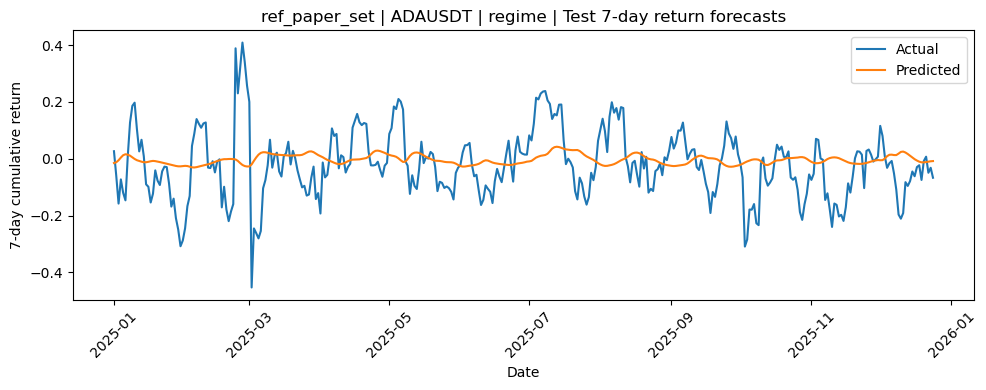

In [40]:

FEATURE_SET_TO_PLOT = list(ACTIVE_FEATURE_SETS.keys())[0]
ASSET_TO_PLOT = assets[0]
PLOT_MODEL = "regime"   # choose "baseline" or "regime"

plot_df = pd.read_csv(
    OUTPUT_DIR / FEATURE_SET_TO_PLOT / ASSET_TO_PLOT / "forecasts.csv",
    parse_dates=["date"],
)
plot_df = plot_df[(plot_df["split"] == "test") & (plot_df["model_type"] == PLOT_MODEL)].copy()

plt.figure(figsize=(10, 4))
plt.plot(plot_df["date"], plot_df["y_true"], label="Actual")
plt.plot(plot_df["date"], plot_df["y_pred"], label="Predicted")
plt.title(f"{FEATURE_SET_TO_PLOT} | {ASSET_TO_PLOT} | {PLOT_MODEL} | Test 7-day return forecasts")
plt.xlabel("Date")
plt.ylabel("7-day cumulative return")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
